## Project Overview

Political speeches occupy a unique place within American history because they provide insight into how leaders have understood the nation, framed major challenges, and articulated visions for the future. Among these speeches, presidential inaugural addresses are particularly significant because they are delivered at pivotal moments of political transition and often attempt to define the priorities, values, and aspirations of a new administration. As a result, inaugural addresses provide a valuable corpus for studying how political rhetoric evolves over time and how presidents communicate with the American public during different historical periods.

The central research question guiding this project is: **How has the language of U.S. presidential inaugural addresses changed over time, and what can computational methods reveal about shifting political priorities and national moods?** More specifically, I am interested in investigating whether periods of major social, economic, or political change correspond with measurable changes in presidential rhetoric. For example, do speeches delivered during wars, economic crises, or periods of social unrest exhibit different linguistic patterns and emotional tones than speeches delivered during relatively stable periods?

To explore these questions, I employ several computational methods discussed throughout Digital Humanities 101, including **word frequency analysis**, **sentiment analysis**, and an exploratory **topic modeling** analysis. Word frequency analysis allows me to identify recurring themes and rhetorical priorities across the corpus. Sentiment analysis provides a quantitative perspective on emotional tone, helping to examine whether presidential rhetoric becomes more optimistic, cautious, hopeful, or fearful during particular historical moments. Finally, topic modeling offers an additional method for identifying broader thematic structures that emerge throughout the speeches.

At the same time, this project is informed by one of the central ideas that has emerged throughout this course: data does not speak for itself. Computational methods can identify patterns that may not be immediately visible through traditional close reading, but those patterns still require interpretation. Consequently, the goal of this project is not to replace historical or literary analysis, but rather to complement it by providing new forms of evidence through which political language can be examined.

The analysis that follows uses the NLTK Inaugural Address Corpus, a publicly accessible collection of presidential inaugural speeches spanning more than two centuries of American history. Through a combination of computational analysis and human interpretation, this project seeks to better understand how presidential rhetoric reflects broader historical conditions and changing conceptions of the nation, government, and public life.

Note: Check out the read me to get started!


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
import re

nltk.download('inaugural')

[nltk_data] Downloading package inaugural to
[nltk_data]     /Users/joeywong/nltk_data...
[nltk_data]   Package inaugural is already up-to-date!


True

## Accessing the Dataset

For this project, I use the **NLTK Inaugural Address Corpus**, which is a publicly available dataset distributed as part of the Natural Language Toolkit (NLTK) library for Python. Rather than manually downloading individual presidential inaugural addresses from Project Gutenberg or another online archive, the corpus can be accessed directly through NLTK after downloading the `inaugural` corpus using `nltk.download('inaugural')`.

The following code imports the corpus and lists every inaugural address available in the dataset:


In [21]:
#extracting the data / preliminary dataset analysis
from nltk.corpus import inaugural
inaugural.fileids()

['1789-Washington.txt',
 '1793-Washington.txt',
 '1797-Adams.txt',
 '1801-Jefferson.txt',
 '1805-Jefferson.txt',
 '1809-Madison.txt',
 '1813-Madison.txt',
 '1817-Monroe.txt',
 '1821-Monroe.txt',
 '1825-Adams.txt',
 '1829-Jackson.txt',
 '1833-Jackson.txt',
 '1837-VanBuren.txt',
 '1841-Harrison.txt',
 '1845-Polk.txt',
 '1849-Taylor.txt',
 '1853-Pierce.txt',
 '1857-Buchanan.txt',
 '1861-Lincoln.txt',
 '1865-Lincoln.txt',
 '1869-Grant.txt',
 '1873-Grant.txt',
 '1877-Hayes.txt',
 '1881-Garfield.txt',
 '1885-Cleveland.txt',
 '1889-Harrison.txt',
 '1893-Cleveland.txt',
 '1897-McKinley.txt',
 '1901-McKinley.txt',
 '1905-Roosevelt.txt',
 '1909-Taft.txt',
 '1913-Wilson.txt',
 '1917-Wilson.txt',
 '1921-Harding.txt',
 '1925-Coolidge.txt',
 '1929-Hoover.txt',
 '1933-Roosevelt.txt',
 '1937-Roosevelt.txt',
 '1941-Roosevelt.txt',
 '1945-Roosevelt.txt',
 '1949-Truman.txt',
 '1953-Eisenhower.txt',
 '1957-Eisenhower.txt',
 '1961-Kennedy.txt',
 '1965-Johnson.txt',
 '1969-Nixon.txt',
 '1973-Nixon.txt',
 '1

In [22]:
print(inaugural.fileids()[:10])

['1789-Washington.txt', '1793-Washington.txt', '1797-Adams.txt', '1801-Jefferson.txt', '1805-Jefferson.txt', '1809-Madison.txt', '1813-Madison.txt', '1817-Monroe.txt', '1821-Monroe.txt', '1825-Adams.txt']


In [23]:
speech = inaugural.raw('1861-Lincoln.txt')

print(speech[:1000])

Fellow-Citizens of the United States: In compliance with a custom as old as the Government itself, I appear before you to address you briefly and to take in your presence the oath prescribed by the Constitution of the United States to be taken by the President "before he enters on the execution of this office."

I do not consider it necessary at present for me to discuss those matters of administration about which there is no special anxiety or excitement.

Apprehension seems to exist among the people of the Southern States that by the accession of a Republican Administration their property and their peace and personal security are to be endangered. There has never been any reasonable cause for such apprehension. Indeed, the most ample evidence to the contrary has all the while existed and been open to their inspection. It is found in nearly all the published speeches of him who now addresses you. I do but quote from one of those speeches when I declare that -- 

I have no purpose, dir

In [24]:
rows = []
for file in inaugural.fileids():
    year = int(file[:4])
    president = file[5:].replace(".txt","")
    text = inaugural.raw(file)
    rows.append(
        {
            "year": year,
            "president": president,
            "speech": text
        }
    )

df = pd.DataFrame(rows)
df.head()

,year,president,speech
0,1789,Washington,Fellow-Citizens of the Senate and of the House...
1,1793,Washington,"Fellow citizens, I am again called upon by the..."
2,1797,Adams,"When it was first perceived, in early times, t..."
3,1801,Jefferson,Friends and Fellow Citizens:\n\nCalled upon to...
4,1805,Jefferson,"Proceeding, fellow citizens, to that qualifica..."


In [25]:
df.to_csv(
    "inaugural_addresses.csv",
    index=False
)

#save the dataset as a csv file for future use

## Dataset Source

While my original project proposal discussed Project Gutenberg as a possible source of inaugural addresses, I ultimately used the NLTK Inaugural Address Corpus because it provides a standardized and publicly accessible collection of presidential inaugural speeches that integrates directly with Python. Using the NLTK corpus also improves reproducibility, since other researchers can access the same dataset directly through the NLTK library without manually downloading or compiling speeches from multiple sources.

## Inspecting the Dataset

Before beginning any analysis, it is important to understand the structure of the dataset being used. In this case, the dataset consists of presidential inaugural addresses spanning more than two centuries of American history. Each observation contains the year of the speech, the president who delivered it, and the full speech text itself.

The code below examines the size and structure of the dataset by displaying its dimensions, column names, and a preview of the first few observations. This step serves as a preliminary validation process, ensuring that the data has been loaded correctly and is organized in a format suitable for further analysis.

In [26]:
print(df.shape)

print(df.columns)

df.head()

(60, 3)
Index(['year', 'president', 'speech'], dtype='object')


,year,president,speech
0,1789,Washington,Fellow-Citizens of the Senate and of the House...
1,1793,Washington,"Fellow citizens, I am again called upon by the..."
2,1797,Adams,"When it was first perceived, in early times, t..."
3,1801,Jefferson,Friends and Fellow Citizens:\n\nCalled upon to...
4,1805,Jefferson,"Proceeding, fellow citizens, to that qualifica..."


The dataset contains presidential inaugural addresses spanning over two centuries. Each observation contains the year, president, and speech text. Before conducting analysis, it is useful to inspect the structure of the dataset and verify that the speeches have been loaded correctly.

## Cleaning and Standardizing the Text

Raw textual data often contains punctuation, capitalization differences, line breaks, and other formatting elements that can interfere with computational analysis. Before conducting word frequency analysis, the speeches must be standardized so that words can be compared consistently across the corpus.

The code below converts all text to lowercase and removes punctuation and special characters using regular expressions. This process reduces unnecessary variation within the dataset. For example, "Freedom," "freedom," and "FREEDOM" should all be treated as the same word during analysis. By cleaning the text in this way, the resulting frequency counts will more accurately reflect meaningful linguistic patterns rather than formatting differences.

In [27]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text

df["clean_text"] = df["speech"].apply(clean_text)

### Before and After Text Cleaning

The impact of text cleaning can be demonstrated through a simple example.

**Original Text:**

```text
"Fellow-Citizens of the United States!"
```

**After Cleaning:**

```text
"fellowcitizens of the united states"
```

Notice that capitalization and punctuation have been removed. While this transformation may appear simple, it is an important step because computational methods analyze text literally. Without standardization, words such as "Freedom," "freedom," and "FREEDOM" would be counted as separate terms despite having the same meaning.

The goal of text cleaning is not to change the content of the speeches, but rather to create a more consistent dataset that allows patterns of language use to be measured more accurately across different presidents, historical periods, and political contexts.

## Tokenization and Stopword Removal

Before conducting word frequency analysis, the speeches must be transformed into a format that Python can analyze more effectively. One important step in this process is **tokenization**, which involves breaking a large body of text into smaller units called *tokens*. In most text analysis projects, tokens are individual words. For example, the sentence:

> "Government of the people, by the people, for the people"

would be tokenized into:

```python
["government", "of", "the", "people", "by", "the", "people", "for", "the", "people"]
```

After tokenization, I remove **stopwords**, which are extremely common words that appear frequently in English but generally contribute little analytical meaning. Examples include words such as "the," "and," "of," and "is." Because these words occur so often, they can dominate frequency counts and obscure more meaningful patterns within the speeches.

The code below first downloads the NLTK stopword list and creates a set of English stopwords. It then loops through every inaugural address in the dataset, tokenizes each speech into individual words, removes stopwords, and stores the remaining words in a master list called `all_words`. This process creates a cleaner corpus that is better suited for identifying recurring themes, rhetorical priorities, and linguistic patterns across presidential inaugural addresses.

In [28]:
import nltk

nltk.download('punkt_tab')

from nltk.corpus import stopwords
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

all_words = []

for speech in df["clean_text"]:

    words = word_tokenize(speech)

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    all_words.extend(words)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/joeywong/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/joeywong/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Example

Original text:

```text
The government of the United States shall...
```

After tokenization:

```python
["the", "government", "of", "the", "united", "states", "shall"]
```

After stopword removal:

```python
["government", "united", "states", "shall"]
```

This allows the analysis to focus on words that are more likely to carry substantive meaning.

## Word Frequency Analysis

Now that the inaugural addresses have been cleaned, tokenized, and stripped of common stopwords, I can begin conducting word frequency analysis. This method measures how often specific words appear throughout the corpus and helps identify recurring themes, rhetorical priorities, and linguistic patterns across presidential inaugural addresses.

The code below uses Python's `Counter()` function to count the frequency of every word contained within the `all_words` list. After generating these counts, I will examine the most common words appearing across the corpus. These results provide an initial overview of the language that presidents have used most frequently when addressing the nation.

At a high level of intuition, this step serves as the foundation for answering my research question. If certain words appear repeatedly across inaugural addresses, they may reveal recurring political concerns, national values, or rhetorical strategies. However, it is important to remember that frequency alone does not explain meaning. Rather, these counts provide a starting point for deeper interpretation and further analysis.

In [29]:
freq = Counter(all_words)

freq.most_common(20)

[('people', 592),
 ('government', 575),
 ('us', 505),
 ('must', 375),
 ('upon', 371),
 ('great', 356),
 ('states', 344),
 ('may', 343),
 ('world', 329),
 ('nation', 323),
 ('country', 321),
 ('shall', 316),
 ('every', 309),
 ('one', 272),
 ('peace', 258),
 ('new', 256),
 ('power', 246),
 ('public', 227),
 ('time', 224),
 ('nations', 224)]

### Interpreting the Results

The output above displays the twenty most frequently occurring words across the corpus. While some words may reflect broad themes of governance, democracy, or national identity, others may simply appear frequently because of the formal nature of political speeches.

Consequently, frequency counts should not be treated as definitive conclusions. Instead, they help identify patterns that warrant closer examination. In the next section, I will visualize these results and investigate whether specific words associated with my research question (e.g., "freedom," "union," "security," "economy," and "democracy") appear differently across historical periods.

## Visualizing Word Frequencies

While numerical frequency counts provide useful information, visualizations make patterns easier to identify and interpret. The code below creates a bar chart displaying the most frequently occurring words across the corpus of presidential inaugural addresses.

By visualizing the data, it becomes easier to compare the relative prominence of different terms and identify recurring themes in presidential rhetoric. This step moves beyond simply counting words and begins the process of interpreting how language has been used across more than two centuries of American political history.

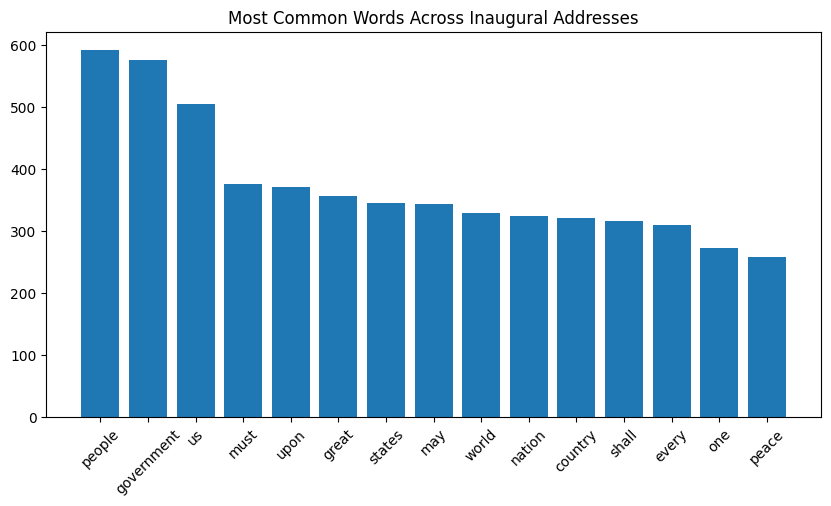

In [30]:
top_words = freq.most_common(15)

words = [x[0] for x in top_words]
counts = [x[1] for x in top_words]

plt.figure(figsize=(10,5))

plt.bar(words, counts)

plt.xticks(rotation=45)

plt.title("Most Common Words Across Inaugural Addresses")

plt.show()

### Interpreting the Visualization

The visualization reveals several interesting patterns within the inaugural corpus. Words such as **"people," "government," "nation," "country,"** and **"peace"** appear frequently, suggesting that presidents consistently emphasize themes of governance, national identity, public service, and civic unity when addressing the nation.

At the same time, it is important to interpret these findings carefully. A high frequency does not necessarily indicate importance in every context, nor does it explain how a word was being used. For example, references to "government" may reflect discussions of federal authority, democratic responsibility, or national challenges, depending on the historical circumstances surrounding a particular speech.

Personally, I think this visualization demonstrates one of the greatest strengths of word frequency analysis. It quickly identifies recurring themes across a large corpus and provides a starting point for deeper investigation. However, it also reinforces an important lesson from digital humanities: computational outputs should be viewed as evidence rather than conclusions. The frequencies reveal patterns, but understanding the significance of those patterns still requires historical context and human interpretation.

In the next section, I will move beyond overall word frequencies and examine specific terms related to my research question, such as **"freedom," "union," "security," "economy,"** and **"democracy,"** in order to explore how presidential language has changed across different historical periods.

## Historical Comparison of Key Political Terms

The previous analysis examined the most common words appearing across the entire corpus. While this provides a useful overview, it does not directly address my research question regarding historical change.

To investigate how presidential rhetoric has evolved over time, I will focus on several terms identified in my project proposal: **freedom, democracy, union, security, and economy**. These words were selected because they represent recurring political themes that may vary in importance across different historical periods.

By comparing the frequency of these terms across different eras, I can begin exploring whether shifts in political priorities correspond with major social, economic, and historical developments.

### Defining Historical Periods

In order to investigate how presidential rhetoric has changed over time, I divided the corpus into three historical periods: speeches delivered before 1900, speeches delivered between 1900 and 1949, and speeches delivered after 1950. While these divisions are somewhat arbitrary, they provide a useful framework for comparing language across different eras of American political history.

In [31]:
early = df[df["year"] < 1900]

middle = df[
    (df["year"] >= 1900)
    & (df["year"] < 1950)
]

modern = df[df["year"] >= 1950]

### Counting Words Within Each Period

The function below combines all speeches within a given historical period and calculates the frequency of each word. This allows me to compare how often specific terms appear across different eras and determine whether certain political themes become more or less prominent over time.

In [32]:
from collections import Counter

def get_word_counts(dataframe):

    text = " ".join(dataframe["clean_text"])

    words = text.split()

    return Counter(words)

### Frequency Dictionaries Created

Using the function above, I created separate word-frequency dictionaries for each historical period. These dictionaries store the number of times each word appears within the speeches of that era and will serve as the basis for the comparisons that follow.

In [33]:
early_freq = get_word_counts(early)

middle_freq = get_word_counts(middle)

modern_freq = get_word_counts(modern)

In [34]:
key_terms = [
    "freedom",
    "democracy",
    "union",
    "security",
    "economy"
]

for term in key_terms:

    print(term)

    print("Before 1900:", early_freq[term])

    print("1900-1949:", middle_freq[term])

    print("1950+:", modern_freq[term])

    print()

freedom
Before 1900: 34
1900-1949: 43
1950+: 111

democracy
Before 1900: 5
1900-1949: 34
1950+: 30

union
Before 1900: 162
1900-1949: 1
1950+: 24

security
Before 1900: 23
1900-1949: 21
1950+: 23

economy
Before 1900: 20
1900-1949: 12
1950+: 21



### Preliminary Findings

Several interesting patterns emerge from these results. The term **"union"** appears far more frequently before 1900 than in later periods, likely reflecting the importance of national unity during the nineteenth century and the years surrounding the Civil War. Meanwhile, terms such as **"freedom"** and **"democracy"** remain relatively common across all three periods, suggesting that they represent enduring themes within presidential rhetoric.

At the same time, these raw frequency counts should be interpreted cautiously. A word's frequency indicates how often it appears, but it does not reveal how the term was used or what specific meaning it carried within a particular historical context. These findings therefore serve as a starting point for further investigation rather than definitive conclusions.

## Comparing Political Language Across Historical Periods

While the previous sections examined overall word frequencies across the entire corpus, my research question is specifically concerned with how presidential language has changed over time. To investigate this question, I selected several politically significant terms that were identified in my project proposal: **freedom, democracy, union, security, and economy**.

These terms were chosen because they represent recurring themes in American political discourse and may reflect changing national priorities across different historical periods. By comparing the frequency of these words before 1900, between 1900 and 1949, and after 1950, I can begin exploring whether shifts in rhetoric correspond with broader social, economic, and political developments.

The table below summarizes the frequency of each term across the three historical periods, while the visualization provides a clearer comparison of how these terms vary over time.

In [35]:
comparison_df = pd.DataFrame({
    "Term": key_terms,
    "Before 1900": [early_freq[t] for t in key_terms],
    "1900-1949": [middle_freq[t] for t in key_terms],
    "1950+": [modern_freq[t] for t in key_terms]
})

comparison_df

,Term,Before 1900,1900-1949,1950+
0,freedom,34,43,111
1,democracy,5,34,30
2,union,162,1,24
3,security,23,21,23
4,economy,20,12,21


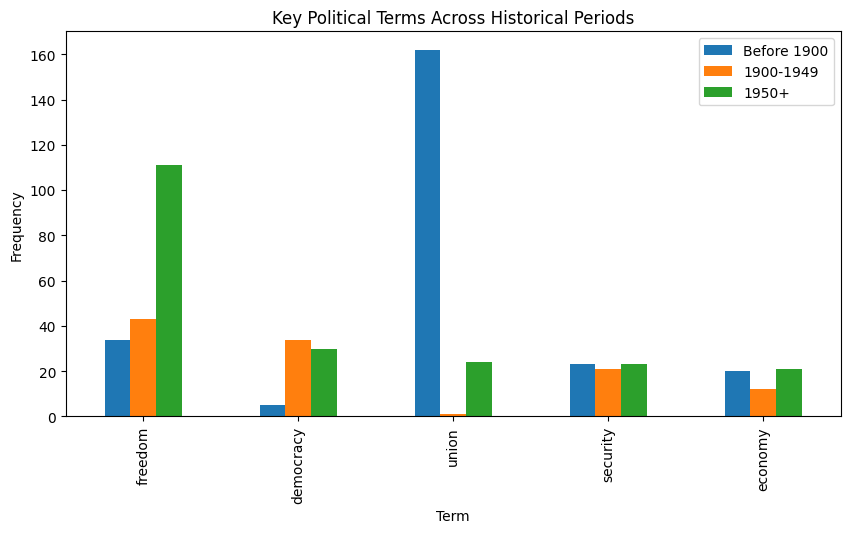

In [36]:
comparison_df.set_index("Term").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Key Political Terms Across Historical Periods"
)

plt.ylabel("Frequency")

plt.show()

## Interpreting the Historical Comparison

Several noteworthy patterns emerge from the visualization. First, the term **"union"** appears overwhelmingly more frequently in speeches delivered before 1900 than in later periods. This result is not entirely surprising given the political significance of national unity during the nineteenth century, particularly in the years surrounding the Civil War. The sharp decline in later periods suggests that presidents gradually shifted their rhetorical focus toward other concerns as the question of preserving the Union became less central to national politics.

In contrast, terms such as **"freedom"** and **"democracy"** become substantially more prominent during the twentieth century and beyond. This may reflect the growing importance of democratic ideals, civil rights, global conflicts, and America's increasing role in international affairs. Likewise, references to **"security"** and **"economy"** remain relatively stable across the periods, suggesting that concerns regarding national safety and economic prosperity have consistently occupied an important place within presidential rhetoric.

Personally, I think these results demonstrate one of the strengths of word frequency analysis. The visualization quickly highlights broad shifts in rhetorical emphasis that might otherwise be difficult to recognize when reading dozens of speeches individually. At the same time, these findings should not be interpreted as definitive explanations of historical change. Frequency counts reveal patterns, but understanding why those patterns emerge requires additional historical context and interpretation. Nevertheless, the results provide preliminary evidence that presidential language does evolve over time and that changing rhetorical priorities may reflect broader transformations within American society and politics.

## Sentiment Analysis

While word frequency analysis helps identify recurring themes and rhetorical priorities, it does not capture the emotional tone of a speech. As discussed in my project proposal, presidents may discuss similar topics while conveying very different emotions depending on the historical circumstances surrounding their inauguration. Consequently, a frequency count alone cannot determine whether a speech is optimistic, fearful, hopeful, or cautious.

To address this limitation, I will conduct sentiment analysis using NLTK's `SentimentIntensityAnalyzer`. Sentiment analysis assigns numerical scores to words and phrases that are generally associated with positive, negative, or neutral emotional valence. By calculating a sentiment score for each inaugural address, I can examine whether presidential rhetoric changes emotionally across different historical periods.

More specifically, I am interested in investigating whether speeches delivered during moments of national crisis exhibit different emotional characteristics than speeches delivered during periods of relative stability. Although sentiment analysis cannot fully capture historical nuance, irony, or rhetorical complexity, it can provide a useful quantitative perspective on changes in presidential language over time.

In [37]:
# Download sentiment lexicon
nltk.download('vader_lexicon')

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Calculate sentiment score for each speech
df["sentiment"] = df["clean_text"].apply(
    lambda text: sia.polarity_scores(text)["compound"]
)

# Display sample results
df[["year", "president", "sentiment"]].head()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/joeywong/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,year,president,sentiment
0,1789,Washington,0.9999
1,1793,Washington,0.5719
2,1797,Adams,1.0000
3,1801,Jefferson,0.9999
4,1805,Jefferson,0.9998


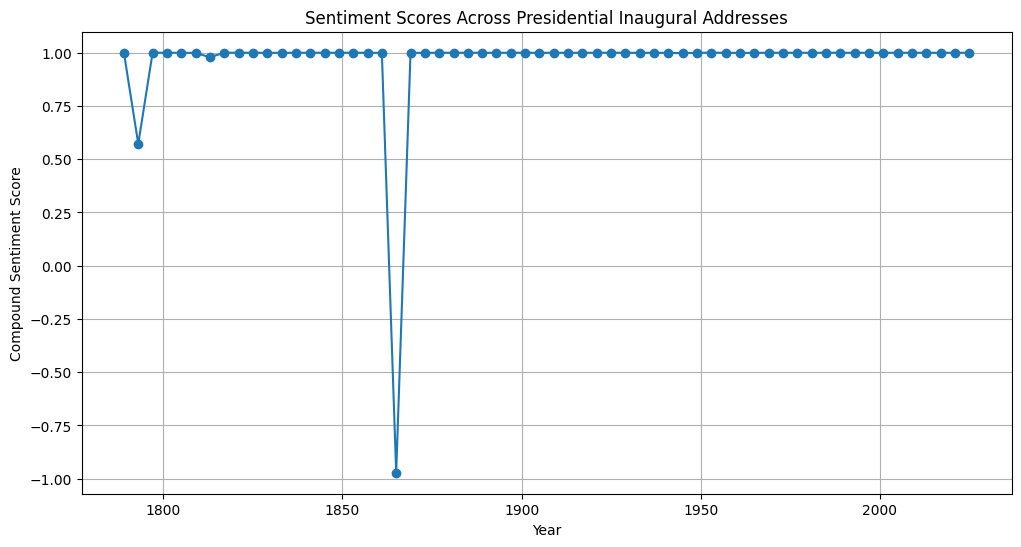

In [38]:
plt.figure(figsize=(12,6))

plt.plot(
    df["year"],
    df["sentiment"],
    marker="o"
)

plt.title(
    "Sentiment Scores Across Presidential Inaugural Addresses"
)

plt.xlabel("Year")

plt.ylabel("Compound Sentiment Score")

plt.grid(True)

plt.show()

In [39]:
early = df[df["year"] < 1900]

middle = df[
    (df["year"] >= 1900)
    & (df["year"] < 1950)
]

modern = df[df["year"] >= 1950]

period_sentiment = pd.DataFrame({
    "Period": [
        "Before 1900",
        "1900-1949",
        "1950+"
    ],
    "Average Sentiment": [
        early["sentiment"].mean(),
        middle["sentiment"].mean(),
        modern["sentiment"].mean()
    ]
})

period_sentiment

,Period,Average Sentiment
0,Before 1900,0.913350
1,1900-1949,0.999631
2,1950+,0.999805


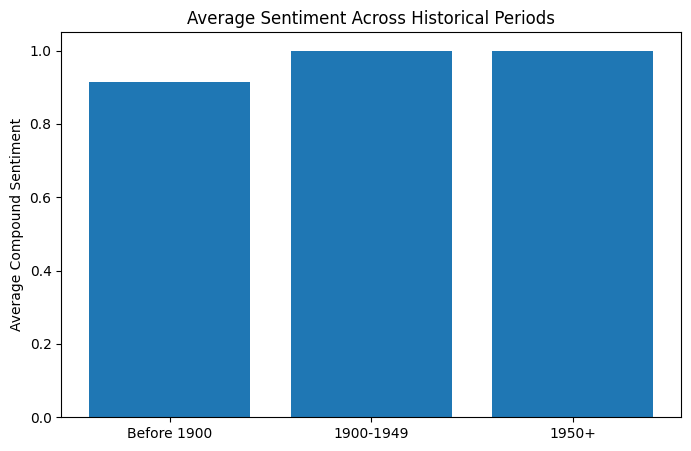

In [40]:
plt.figure(figsize=(8,5))

plt.bar(
    period_sentiment["Period"],
    period_sentiment["Average Sentiment"]
)

plt.title(
    "Average Sentiment Across Historical Periods"
)

plt.ylabel("Average Compound Sentiment")

plt.show()

## Interpreting the Results

The results reveal a surprisingly consistent pattern across all three historical periods. Every period exhibits a highly positive average sentiment score, suggesting that presidential inaugural addresses have historically been characterized by optimism, encouragement, and aspirational language. While speeches delivered before 1900 have a slightly lower average sentiment score (0.913) than those delivered during the twentieth and twenty-first centuries, the overall differences between periods are relatively modest.

One possible explanation for this pattern is the unique purpose of inaugural addresses themselves. Unlike campaign speeches, political debates, or wartime addresses, inaugural speeches are often intended to promote national unity, inspire public confidence, and articulate a vision for the future. Consequently, presidents may be inclined to adopt a generally positive tone regardless of the specific challenges facing the nation at the time.

Interestingly, while average sentiment remained highly positive across periods, individual speeches occasionally deviated from this pattern. One notable example appears during the Civil War era, where a speech received a substantially lower sentiment score than the rest of the corpus. This suggests that moments of national crisis may still be visible at the level of individual speeches, even when broader historical averages remain overwhelmingly positive.

At the same time, these findings should be interpreted carefully. The consistently high sentiment scores may suggest a limitation of computational sentiment analysis when applied to political rhetoric. Presidential speeches often contain formal, ceremonial language that naturally produces positive sentiment scores, even when discussing periods of conflict, uncertainty, or crisis. Additionally, because the sentiment analysis model was developed using contemporary language, it may not fully capture the nuances of nineteenth-century political speech.

Personally, I find these results particularly interesting because they both support and complicate my original research question. While I expected major historical events to produce larger differences in emotional tone, the findings suggest that presidents have consistently used inaugural addresses as opportunities to project hope, confidence, and national unity. This reinforces one of the central lessons of digital humanities: computational methods can reveal important patterns, but those patterns still require historical interpretation and critical reflection.

## Exploratory Topic Modeling (Note: This is an extra portion. This was done on my own term, beyond the course and was not part of my original intended methods)

While word frequency analysis identifies commonly used words and sentiment analysis measures emotional tone, neither method directly identifies broader thematic patterns within the speeches. To further explore my research question, I conducted a preliminary topic modeling analysis.

Topic modeling is a computational technique that groups words that frequently appear together and attempts to identify underlying themes within a collection of texts. Rather than focusing on individual words, topic modeling helps reveal larger patterns of discussion that may characterize different historical periods.

Because this method was not part of my original project proposal, I treat it as an exploratory extension rather than a primary analytical tool (this was also suggested by Rae). Nevertheless, it offers an additional perspective on how presidential priorities and concerns may have changed over time.

In [41]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

### Creating a Document-Term Matrix

Before topic modeling can be performed, the textual data must be transformed into a numerical representation. Computers cannot directly identify themes from raw text, so the speeches must first be converted into a structured format that records which words appear in each document.

The code below uses Scikit-Learn's `CountVectorizer` to create a **document-term matrix (DTM)**. A document-term matrix is a table in which each row represents a document (in this case, an inaugural address) and each column represents a unique word. The values within the matrix indicate how frequently each word appears in each speech.

Several parameters are applied to improve the quality of the analysis. English stopwords are removed because they contribute little substantive meaning, while extremely rare and extremely common words are filtered out using the `min_df` and `max_df` settings. This helps ensure that the topic model focuses on meaningful patterns of language rather than words that appear either too infrequently or too universally across the corpus.

In [42]:
vectorizer = CountVectorizer(
    stop_words="english",
    max_df=0.95,
    min_df=2
)

dtm = vectorizer.fit_transform(
    df["clean_text"]
)

### Interpreting the Document-Term Matrix

At this stage, the inaugural addresses have been converted from raw text into a numerical structure that can be analyzed computationally. While the document-term matrix itself is not particularly interpretable to a human reader, it serves as the foundation for the topic modeling process.

Conceptually, the matrix allows the algorithm to identify which words frequently appear together across speeches. Rather than examining individual speeches one at a time, the model can now analyze patterns across the entire corpus simultaneously. This transformation is an important example of how computational methods operate within digital humanities research. Textual documents remain the primary source of evidence, but they must first be translated into a format that allows large-scale analysis.

The document-term matrix therefore serves as a bridge between traditional textual interpretation and computational analysis. In the next step, the topic modeling algorithm will use this matrix to identify groups of related words that may represent recurring themes within presidential inaugural rhetoric.

In [43]:
print(type(dtm))
print(dtm.shape)

vocab = vectorizer.get_feature_names_out()
print(vocab[:20])

<class 'scipy.sparse._csr.csr_matrix'>
(60, 5050)
['abandon' 'abandoned' 'abandonment' 'abiding' 'abilities' 'ability'
 'able' 'abolish' 'abolished' 'aboriginal' 'abraham' 'abreast' 'abroad'
 'absence' 'absent' 'absolute' 'absolutely' 'abstain' 'abundance'
 'abundant']


The document-term matrix is stored as a sparse matrix in which rows represent inaugural addresses and columns represent unique terms. Each value records how often a particular word appears within a speech. The learned vocabulary confirms that the vectorizer successfully transformed the cleaned corpus into a numerical representation suitable for topic modeling.

### Training the Topic Model

With the document-term matrix prepared, I can now apply a topic modeling algorithm to identify recurring themes within the inaugural corpus. For this project, I use **Latent Dirichlet Allocation (LDA)**, one of the most widely used topic modeling techniques in computational text analysis.

LDA works by identifying groups of words that frequently appear together across documents. These groups are interpreted as topics that represent broader themes within the corpus. In this implementation, I instruct the model to identify **five topics**, meaning that the algorithm will attempt to organize the speeches into five major thematic clusters.

The `random_state` parameter is included to ensure reproducibility. This allows the analysis to generate consistent results each time the notebook is executed, which is an important consideration for transparent and replicable digital humanities research.

In [44]:
lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

lda.fit(dtm)

LatentDirichletAllocation(n_components=5, random_state=42)

### Interpreting the Model Output

The output above confirms that the Latent Dirichlet Allocation model was successfully created and fitted to the document-term matrix. At this stage, the model has analyzed the relationships among thousands of words appearing throughout the inaugural corpus and identified patterns that will be used to generate topics.

However, the model itself does not yet provide directly interpretable results. The output simply confirms the parameters used to construct the topic model, including the number of topics selected for analysis. The actual thematic content of each topic will become visible in the next step, where I extract and examine the most significant words associated with each topic.

In other words, this stage can be viewed as the "training" phase of the topic model. The algorithm has learned patterns from the corpus, but those patterns must still be translated into human-readable themes through interpretation of the topic-word distributions generated in the following section.

### Extracting Topics from the Model

After training the topic model, the next step is to examine the words that the algorithm associates with each topic. Although the model has already identified patterns within the corpus, those patterns are not yet interpretable to a human reader. To better understand the topics, I extract the ten most important words associated with each thematic cluster.

The code below retrieves the vocabulary generated by the `CountVectorizer` and then identifies the highest-weighted words within each topic. These words provide insight into the themes that the algorithm detected throughout the inaugural corpus. It is important to note that topic labels are not automatically generated. Instead, researchers must examine the words within each topic and determine what broader theme or concept they appear to represent.

This step therefore represents an important intersection between computational analysis and human interpretation. The algorithm identifies patterns, but it is ultimately the researcher who assigns meaning to those patterns.

In [45]:
feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):

    print(f"\nTopic {topic_idx + 1}")

    top_words = [
        feature_names[i]
        for i in topic.argsort()[-10:]
    ]

    print(", ".join(top_words))


Topic 1
law, laws, national, country, great, constitution, states, public, shall, government

Topic 2
promises, combinations, countrys, countrymen, inhabitants, escape, activity, support, american, islands

Topic 3
foreign, war, public, shall, union, united, great, country, states, government

Topic 4
let, great, government, time, peace, freedom, new, nation, america, world

Topic 5
executive, spirit, rights, citizens, states, constitution, country, great, power, government


## Interpreting the Topic Model Results

The topic model identified five recurring thematic clusters within the corpus of presidential inaugural addresses. Although the boundaries between topics are not perfectly distinct, several meaningful patterns emerge.

**Topic 1** appears to focus on governance, constitutional authority, and public institutions. Words such as "constitution," "states," "public," and "government" suggest discussions of political structure, law, and the responsibilities of government.

**Topic 2** appears to emphasize the American people and civic participation. Terms such as "countrymen," "inhabitants," "support," and "American" suggest a focus on citizens and the relationship between leaders and the public.

**Topic 3** appears to center on national unity, foreign affairs, and conflict. The presence of words such as "foreign," "war," "union," and "united" suggests discussions related to national security, diplomacy, and preserving the nation during periods of challenge.

**Topic 4** appears to emphasize national ideals and aspirations. Words such as "peace," "freedom," "nation," "America," and "world" suggest discussions of democratic values, international relationships, and visions for the country's future.

**Topic 5** appears to focus on citizenship, rights, and political power. Terms such as "rights," "citizens," "constitution," and "power" indicate recurring discussions about civic responsibilities and constitutional principles.

Taken together, these topics reinforce many of the findings from the earlier word frequency analysis. Themes related to government, national identity, freedom, citizenship, and public service consistently emerge throughout the corpus. This suggests that while individual presidents may differ in style and historical context, inaugural addresses often revolve around a relatively stable set of core political concerns.

Personally, I find the topic modeling results particularly interesting because they reveal relationships among words rather than examining individual words in isolation. For example, seeing "freedom," "peace," "America," and "world" grouped together suggests that presidents frequently connect domestic ideals with broader international aspirations. At the same time, the results demonstrate one of the limitations of topic modeling: the algorithm can identify clusters of related words, but it cannot explain why those relationships exist. Historical context and human interpretation remain necessary for transforming computational outputs into meaningful historical insights.

# Reflection

## What Worked

One aspect of the project that worked particularly well was the use of the NLTK Inaugural Address Corpus. Because the dataset was already organized and publicly accessible, I was able to focus more of my effort on analysis rather than data collection. The word frequency analysis, sentiment analysis, and topic modeling techniques all executed successfully and produced interpretable results. Additionally, the visualizations helped make larger patterns within the corpus easier to identify.

## What Did Not Work

One challenge involved sentiment analysis. The sentiment scores were overwhelmingly positive across nearly all speeches, which made it difficult to distinguish meaningful differences between historical periods. This suggests that either inaugural addresses are inherently optimistic documents or that the sentiment model struggles to capture the nuances of historical political rhetoric.

## Challenges

The most difficult aspect of the project was understanding how computational methods translate text into numerical representations. Topic modeling was particularly challenging because the model generated clusters of words without automatically explaining what those clusters meant. Interpreting the topics required substantial human judgment and historical reasoning.

## What I Learned

This project reinforced one of the central lessons of digital humanities: computational outputs do not speak for themselves. Word frequencies, sentiment scores, and topic models can identify patterns, but they still require interpretation. Personally, I learned that computational methods are most useful when they generate new questions rather than definitive answers. The project also demonstrated how Python can be used to analyze large collections of texts in ways that would be difficult to accomplish through close reading alone while still requiring traditional humanities skills to contextualize the results.

# Reflection on the Coding Process

## What Proved Too Time-Consuming?

The most time-consuming aspect of this project was preprocessing the text and deciding how to clean the corpus before analysis. Although downloading the NLTK Inaugural Address Corpus was straightforward, transforming the speeches into a format suitable for computational analysis required multiple stages of cleaning, tokenization, stopword removal, and validation. I also spent a considerable amount of time interpreting the results rather than simply generating them. Producing graphs and numerical outputs was relatively easy, but determining what those outputs actually suggested about changes in presidential rhetoric required careful historical consideration.

## What Parts of Coding in Python Were Challenging?

Several aspects of Python were initially challenging. Working with pandas DataFrames, applying functions across entire columns, and understanding how different libraries interacted required practice. I also encountered issues with downloading NLTK resources, managing package dependencies, and debugging errors such as missing variables or unavailable corpora. Learning how to combine multiple libraries (e.g., NLTK, pandas, Matplotlib, and scikit-learn) into one coherent workflow was one of the biggest technical challenges throughout the project.

## What Aspects of My Chosen Methods Were Difficult to Implement or Understand?

The most challenging method to understand was topic modeling. Unlike word frequency analysis or sentiment analysis, topic modeling does not automatically produce human-readable themes. Instead, the Latent Dirichlet Allocation (LDA) model generates clusters of statistically related words that must be interpreted by the researcher. Determining what each topic represented required both computational understanding and historical reasoning. I also found it challenging to choose appropriate preprocessing parameters, such as stopword removal and document-term matrix settings, because small changes to these decisions could substantially alter the resulting topics.

Sentiment analysis also presented interpretive challenges. Most inaugural addresses received highly positive sentiment scores, making it difficult to distinguish meaningful historical differences between speeches. This highlighted one of the limitations of computational methods: numerical results alone do not always capture the complexity of historical rhetoric.

Overall, this project demonstrated that computational methods can efficiently identify patterns within large collections of texts, but meaningful interpretation still depends on critical thinking and historical context. While writing the code became easier with practice, understanding how to evaluate and interpret the results proved to be the most valuable part of the learning process.